# 1. Persiapan Data

## 1.1 Load Dataset

In [3]:
import pandas as pd

TRAIN_PATH = 'data_training.csv'
TEST_PATH  = 'data_testing.csv'

df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)

print(f'Data Training : {df_train.shape[0]} baris, {df_train.shape[1]} kolom')
print(f'Data Testing  : {df_test.shape[0]} baris, {df_test.shape[1]} kolom')

Data Training : 857 baris, 13 kolom
Data Testing  : 286 baris, 12 kolom


## 1.2 Tampilan Awal Data

In [4]:
print('=== Statistik Deskriptif ===')
df_train.describe().round(3)

=== Statistik Deskriptif ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000
mean,8.262,0.529,0.267,2.506,0.087,15.783,45.978,0.997,3.313,0.657,10.430,5.653,813.749
std,1.702,0.179,0.195,1.294,0.049,10.300,31.692,0.002,0.152,0.167,1.067,0.822,463.807
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.390,8.400,3.000,0.000
25%,7.100,0.395,0.090,1.900,0.070,7.000,21.000,0.996,3.210,0.550,9.500,5.000,413.000
50%,7.900,0.520,0.250,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000,814.000
75%,9.100,0.640,0.420,2.600,0.090,21.000,63.000,0.998,3.400,0.730,11.100,6.000,1214.000
max,15.600,1.580,1.000,15.500,0.611,68.000,278.000,1.003,4.010,2.000,14.000,8.000,1597.000


Data berisi 857 wine tanpa missing value.

Mayoritas wine dalam dataset adalah wine dengan kualitas sedang (5,65).

## 1.3 Distribusi Kualitas Wine

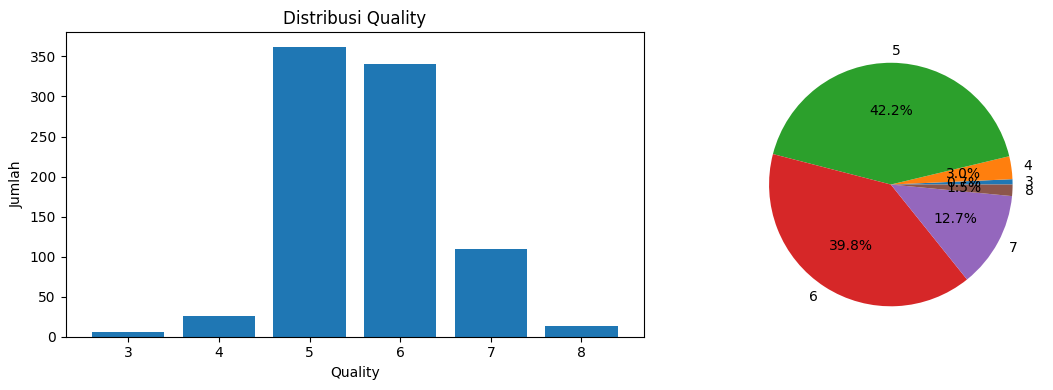

quality
3      6
4     26
5    362
6    341
7    109
8     13
Name: count, dtype: int64


In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

qc = df_train['quality'].value_counts().sort_index()

# Bar chart
ax[0].bar(qc.index, qc.values)
ax[0].set(title='Distribusi Quality', xlabel='Quality', ylabel='Jumlah')

# Pie chart
ax[1].pie(qc.values, labels=qc.index, autopct='%1.1f%%')

plt.tight_layout()
plt.show()

print(qc)

Distribusi kelas sangat tidak seimbang. Kelas 5 dan 6 mendominasi dataset, sementara kelas 3 dan 8 sangat sedikit.

## 1.4 Korelasi Kandungan dan Kualitas Wine

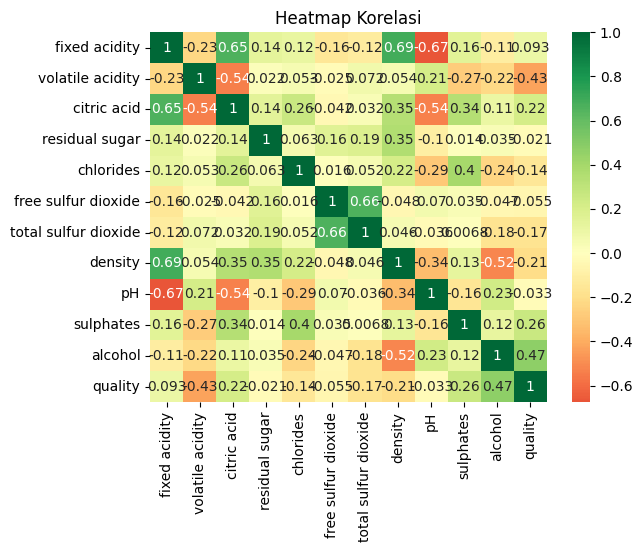

alcohol                 0.473555
sulphates               0.260703
citric acid             0.221263
fixed acidity           0.092714
residual sugar         -0.020511
pH                     -0.033199
free sulfur dioxide    -0.054509
chlorides              -0.144946
total sulfur dioxide   -0.172737
density                -0.207903
volatile acidity       -0.430059
Name: quality, dtype: float64


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

FEATURE_COLS = [col for col in df_train.columns if col not in ['quality', 'Id']]
cols = FEATURE_COLS + ['quality']
corr = df_train[cols].corr()

sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0)
plt.title('Heatmap Korelasi')
plt.show()

print(corr['quality'].drop('quality').sort_values(ascending=False))

alcohol memiliki korelasi positif tertinggi terhadap quality, artinya anggur dengan kadar alkohol lebih tinggi cenderung berkualitas lebih baik. Sebaliknya, volatile acidity dan density berkorelasi negatif terhadap quality.

## 1.5 Pemisahan Fitur dan Target (Kualitas)

In [9]:
X            = df_train[FEATURE_COLS]
y            = df_train['quality']
X_test_final = df_test[FEATURE_COLS]
ids_test     = df_test['Id']

print(f'Shape X (fitur training) : {X.shape}')
print(f'Shape y (target)         : {y.shape}')
print(f'Shape X_test_final       : {X_test_final.shape}')
print(f'\nFitur yang digunakan ({len(FEATURE_COLS)}):')
for i, col in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2d}. {col}')

Shape X (fitur training) : (857, 11)
Shape y (target)         : (857,)
Shape X_test_final       : (286, 11)

Fitur yang digunakan (11):
   1. fixed acidity
   2. volatile acidity
   3. citric acid
   4. residual sugar
   5. chlorides
   6. free sulfur dioxide
   7. total sulfur dioxide
   8. density
   9. pH
  10. sulphates
  11. alcohol


# 2. Pembersihan Data

## 2.1 Deteksi Missing Value

In [10]:
print('=== Missing Values — Data Training ===')
mv_train = df_train.isnull().sum()
print(mv_train)
print(f'\nTotal missing (training) : {mv_train.sum()}')

print('\n=== Missing Values — Data Testing ===')
mv_test = df_test.isnull().sum()
print(mv_test)
print(f'Total missing (testing)  : {mv_test.sum()}')

=== Missing Values — Data Training ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Total missing (training) : 0

=== Missing Values — Data Testing ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64
Total missing (testing)  : 0


Tidak terdapat missing value.

## 2.2 Deteksi Duplikasi

In [12]:
print("Duplikasi train:", df_train.duplicated().sum())
print("Duplikasi test :", df_test.duplicated().sum())

df_train = df_train.drop_duplicates().reset_index(drop=True)

Duplikasi train: 0
Duplikasi test : 0


Tidak terdapat duplikat

## 2.3 Deteksi Outlier

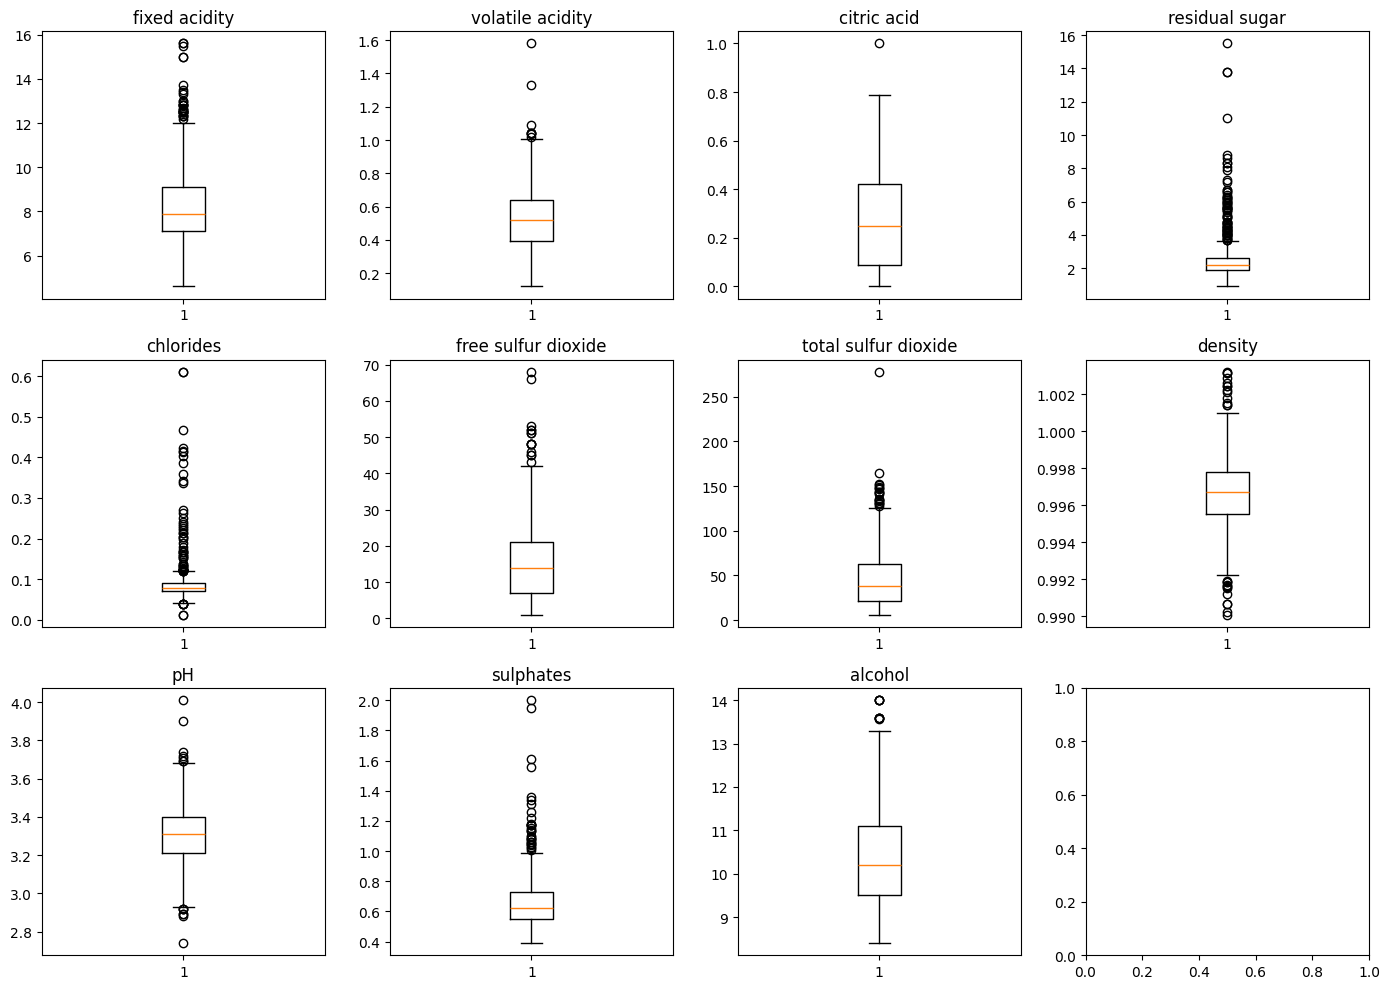

In [13]:
fig, ax = plt.subplots(3, 4, figsize=(14, 10))
ax = ax.flatten()

for i, col in enumerate(FEATURE_COLS):
    ax[i].boxplot(df_train[col].dropna())
    ax[i].set_title(col)

plt.tight_layout()
plt.show()

Beberapa fitur seperti chlorides, residual sugar, dan free sulfur dioxide menunjukkan adanya outlier. Karena model yang digunakan adalah Random Forest yang bersifat robust terhadap outlier, data ekstrem tidak dihapus agar tidak kehilangan informasi.

## 2.4 Feature Scalling

StandardScaler di-fit hanya menggunakan data training, lalu diterapkan (transform) pada data testing. Dilakukan untuk menghindari data leakage dari data testing ke model.

In [15]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test_final)

joblib.dump(scaler, 'scaler_wine.pkl')

['scaler_wine.pkl']

## 2.5 Train-Validation Split

Train-validation split digunakan untuk membagi data jadi data belajar dan data uji sementara, supaya bisa cek apakah model sudah bagus atau belum.

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_val.shape)

(685, 11) (172, 11)


# 3. Pembuatan Model

## 3.1 Justifikasi Pemilihan Model

Random Forest dipilih karena cocok untuk data tabular multi-kelas, tahan terhadap outlier, tidak terlalu sensitif skala fitur, bisa menunjukkan fitur penting, dan biasanya akurat tanpa banyak tuning serta membantu mengurangi overfitting.

## 3.2 Evaluasi Model

0.627906976744186


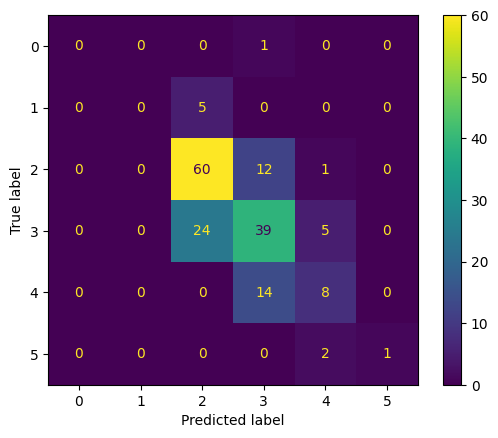

In [36]:
acc = accuracy_score(y_val, rf.predict(X_val))
print(acc)

cm = confusion_matrix(y_val, rf.predict(X_val))
ConfusionMatrixDisplay(cm).plot()
plt.show()

Model berhasil memprediksi dengan benar sekitar 62,79% dari data validasi.

Model cukup bagus untuk kelas yang sering muncul (5 dan 6), tapi masih sering salah di kelas yang jarang.

## 3.2.2 Cross-Validation Score

In [27]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf, X_scaled, y,
    cv=cv_strategy, scoring='accuracy', n_jobs=-1
)

print('=== 5-Fold Stratified Cross-Validation ===')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i} : {score:.4f}')
print(f'\n  Mean  : {cv_scores.mean():.4f}')
print(f'  Std   : {cv_scores.std():.4f}')
print(f'  Min   : {cv_scores.min():.4f}')
print(f'  Max   : {cv_scores.max():.4f}')

=== 5-Fold Stratified Cross-Validation ===
  Fold 1 : 0.5988
  Fold 2 : 0.6570
  Fold 3 : 0.6491
  Fold 4 : 0.6316
  Fold 5 : 0.6784

  Mean  : 0.6430
  Std   : 0.0267
  Min   : 0.5988
  Max   : 0.6784


Model punya akurasi sekitar 64% dan cukup konsisten di berbagai pembagian data.

## 3.3.3 Classification Report

In [29]:
from sklearn.metrics import classification_report

y_pred = rf.predict(X_val)

print('=== Classification Report ===')
print(classification_report(y_val, y_pred, zero_division=0))

=== Classification Report ===
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.67      0.82      0.74        73
           6       0.59      0.57      0.58        68
           7       0.50      0.36      0.42        22
           8       1.00      0.33      0.50         3

    accuracy                           0.63       172
   macro avg       0.46      0.35      0.37       172
weighted avg       0.60      0.63      0.61       172



Model cukup baik untuk kelas yang banyak datanya (5 & 6), tapi kesulitan mengenali kelas yang jarang.

## 4. Prediksi Data Uji

## 4.1 Prediksi Kualitas Anggur

In [38]:
y_test_pred = rf.predict(X_test_scaled)

# Count per kelas
pred_dist = pd.Series(y_test_pred).value_counts().sort_index()
print('=== Jumlah Prediksi per Kelas Quality ===')
for kelas, count in pred_dist.items():
    print(f'  Quality {kelas} : {count} sampel')

print(f'\nTotal : {len(y_test_pred)} sampel')

# List Id beserta hasil prediksi quality
df_hasil = pd.DataFrame({
    'Id'     : ids_test.values,
    'quality': y_test_pred
})

print('\n=== Daftar Id dan Hasil Prediksi Quality ===')
print(df_hasil.to_string(index=False))

=== Jumlah Prediksi per Kelas Quality ===
  Quality 5 : 141 sampel
  Quality 6 : 125 sampel
  Quality 7 : 20 sampel

Total : 286 sampel

=== Daftar Id dan Hasil Prediksi Quality ===
  Id  quality
 222        5
1514        6
 417        5
 754        5
 516        5
1120        7
 180        5
  82        5
 632        6
 592        5
 501        7
1586        6
1096        5
1101        6
1488        5
 700        5
 631        6
1022        5
1420        5
 882        7
1170        6
 911        5
 124        5
1417        7
 681        5
  63        5
1010        6
 418        6
 399        5
1265        6
 999        5
 452        6
 347        7
 778        6
 607        5
  32        5
 511        6
1035        6
1270        6
 723        6
 838        7
 485        6
 142        6
1470        5
1238        5
 158        5
 426        5
 344        6
 637        5
1578        6
 944        6
 469        5
 148        5
 279        7
1144        6
 509        7
1073        6
1423  

## 4.2 Visualisasi Hasil Prediksi

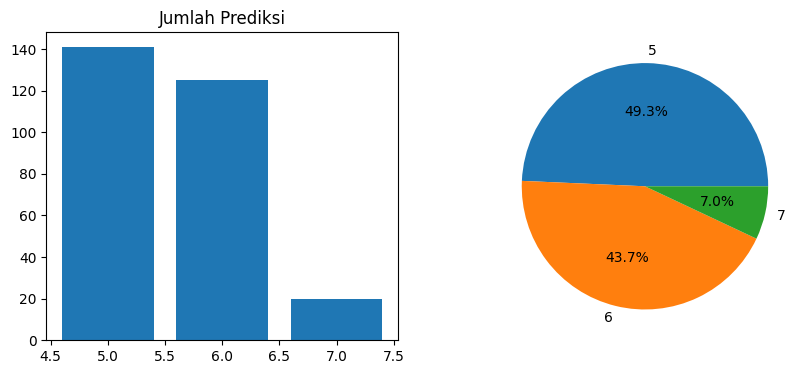

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Bar
ax[0].bar(pred_dist.index, pred_dist.values)
ax[0].set_title('Jumlah Prediksi')

# Pie
ax[1].pie(pred_dist.values, labels=pred_dist.index, autopct='%1.1f%%')

plt.show()

Dari bar chart dan pie chart bersebut, terlihat bahwa model sangat condong ke kelas tengah (5 & 6), tetapi jarang memprediksi kelas tinggi atau rendah. Artinya model sudah menangkap pola umum, tapi belum bisa membedakan kualitas ekstrem dengan baik.